Given a salary dataset with years of experience and the corresponding salary, use an ML model to predict new salary of people based on some different years of experience.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
ds = pd.read_csv("Salary_data.csv")
X = ds["YearsExperience"].values
Y = ds["Salary"].values

In [7]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [8]:
Y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

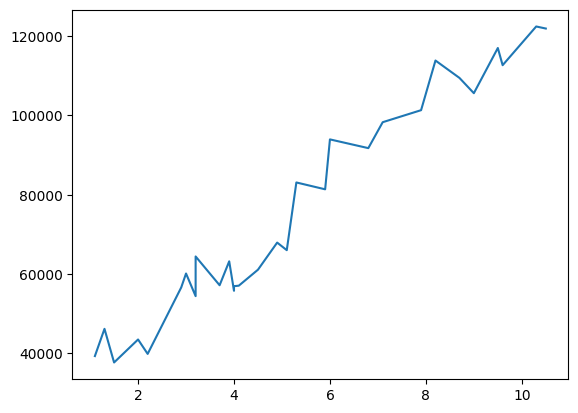

In [9]:
plt.plot(X, Y)

In [10]:
X = np.array(X)
Y = np.array(Y)

### Normalizing the dataset

In [11]:
def mean(X):
    return np.sum(X)/len(X)

### Variance

In [12]:
def variance(X):
    mean_value = mean(X)
    return np.sum((X-mean_value)**2)

### Norm

In [13]:
def norm(X):
    mean_value = mean(X)
    variance_value = variance(X)
    return (X - mean_value)/np.sqrt(variance_value)

In [14]:
X_norm = norm(X)

In [15]:
X_norm

array([-0.27569669, -0.26260982, -0.24952295, -0.21680578, -0.20371891,
       -0.15791487, -0.15137144, -0.13828457, -0.13828457, -0.1055674 ,
       -0.09248053, -0.0859371 , -0.0859371 , -0.07939367, -0.05321993,
       -0.02704619, -0.01395933, -0.00087246,  0.03838815,  0.04493158,
        0.09727905,  0.11690935,  0.16925683,  0.18888713,  0.2216043 ,
        0.2412346 ,  0.27395177,  0.2804952 ,  0.32629924,  0.33938611])

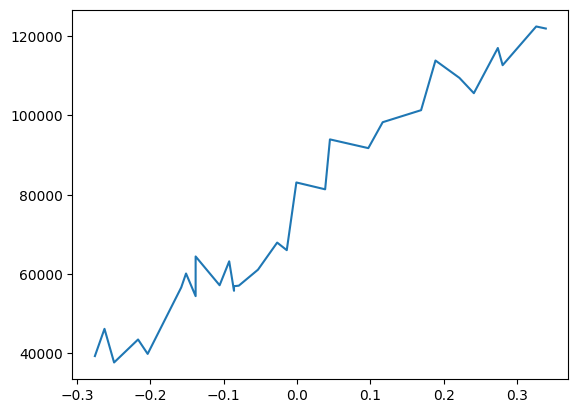

In [17]:
plt.plot(X_norm,Y)

### Using `sckit-learn` to implement linear regression

https://scikit-learn.org/stable/modules/linear_model.html

In [18]:
!pip install scikit-learn

In [19]:
from sklearn.linear_model import LinearRegression

In [24]:
X_norm = X_norm.reshape(-1,1)

In [25]:
reg = LinearRegression().fit(X_norm, Y)

### Regression Score

In [26]:
reg.score(X_norm, Y)

0.9569566641435086

### Coefficient 

In [27]:
reg.coef_

array([144419.00602182])

### Intercept

In [29]:
reg.intercept_    # intercept or bias

np.float64(76003.0)

In [31]:
y_pred = reg.predict(X_norm)

In [32]:
y_pred

array([ 36187.15875227,  38077.15121656,  39967.14368085,  44692.12484158,
        46582.11730587,  53197.09093089,  54142.08716303,  56032.07962732,
        56032.07962732,  60757.06078805,  62647.05325234,  63592.04948449,
        63592.04948449,  64537.04571663,  68317.03064522,  72097.0155738 ,
        73987.00803809,  75877.00050238,  81546.97789525,  82491.9741274 ,
        90051.94398456,  92886.932681  , 100446.90253816, 103281.8912346 ,
       108006.87239533, 110841.86109176, 115566.84225249, 116511.83848464,
       123126.81210966, 125016.80457395])

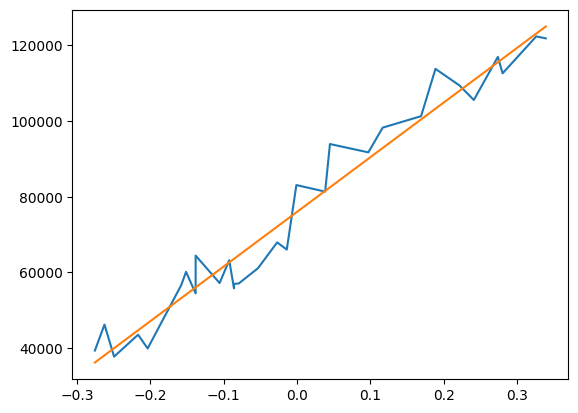

In [33]:
plt.plot(X_norm, Y)
plt.plot(X_norm, y_pred)